# Phase 2: Exploratory Data Analysis
## Blood Cancer Detection — Hybrid Dataset

> **Synthetic-data caveat:** Columns `RBC_M_per_uL`, `Hemoglobin_g_dL`, `Hematocrit_pct`, `MCV_fL`, `MCH_pg`, `MCHC_g_dL`, `Neutrophils_pct`, `Lymphocytes_pct`, `Monocytes_pct`, `Eosinophils_pct`, `Basophils_pct`, and `Blasts_pct` were **generated synthetically** from published clinical reference ranges (see `docs/cbc_reference_ranges.md`). All remaining columns are real patient records from the Mendeley Bangladesh dataset (CC BY 4.0). Model performance on synthetic features reflects pipeline methodology, not clinical validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT = Path('..')
DATA    = PROJECT / 'data'
OUT     = PROJECT / 'outputs' / 'eda'
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

df = pd.read_csv(DATA / 'blood_cancer_hybrid.csv')
df['Total WBC count(/cumm)'] = pd.to_numeric(df['Total WBC count(/cumm)'], errors='coerce')
df['Platelet Count( (/cumm)'] = pd.to_numeric(df['Platelet Count( (/cumm)'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

CBC_COLS = [
    'RBC_M_per_uL', 'Hemoglobin_g_dL', 'Hematocrit_pct',
    'MCV_fL', 'MCH_pg', 'MCHC_g_dL',
    'Neutrophils_pct', 'Lymphocytes_pct', 'Monocytes_pct',
    'Eosinophils_pct', 'Basophils_pct', 'Blasts_pct',
]
REAL_NUM = ['Total WBC count(/cumm)', 'Platelet Count( (/cumm)']
ALL_NUM  = CBC_COLS + REAL_NUM

CLASSES = ['Normal','ALL','AML','CLL','CML','Lymphoma','Multiple Myeloma']
PALETTE = dict(zip(CLASSES, sns.color_palette('Set2', len(CLASSES))))
print('Loaded:', df.shape)


Loaded: (1579, 28)


In [2]:
summary_path = PROJECT / 'reports' / 'phase2_eda_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('=== EDA SUMMARY - blood_cancer_hybrid.csv ===\n\n')
    f.write(f'Shape: {df.shape}\n\n')
    f.write('=== DTYPES ===\n')
    f.write(df.dtypes.to_string())
    f.write('\n\n=== LABEL value_counts ===\n')
    f.write(df['label'].value_counts().to_string())
    f.write('\n\n=== MISSING VALUES (count per column) ===\n')
    miss = df.isnull().sum()
    f.write(miss[miss > 0].to_string() if miss.any() else 'None')
    f.write('\n\n=== NUMERIC DESCRIBE ===\n')
    f.write(df[ALL_NUM].describe().round(3).to_string())
    f.write('\n\n=== head(5) ===\n')
    f.write(df.head(5).to_string())
print(f'Summary -> {summary_path}')


Summary -> ..\reports\phase2_eda_summary.txt


### Chart 1 — Class Distribution

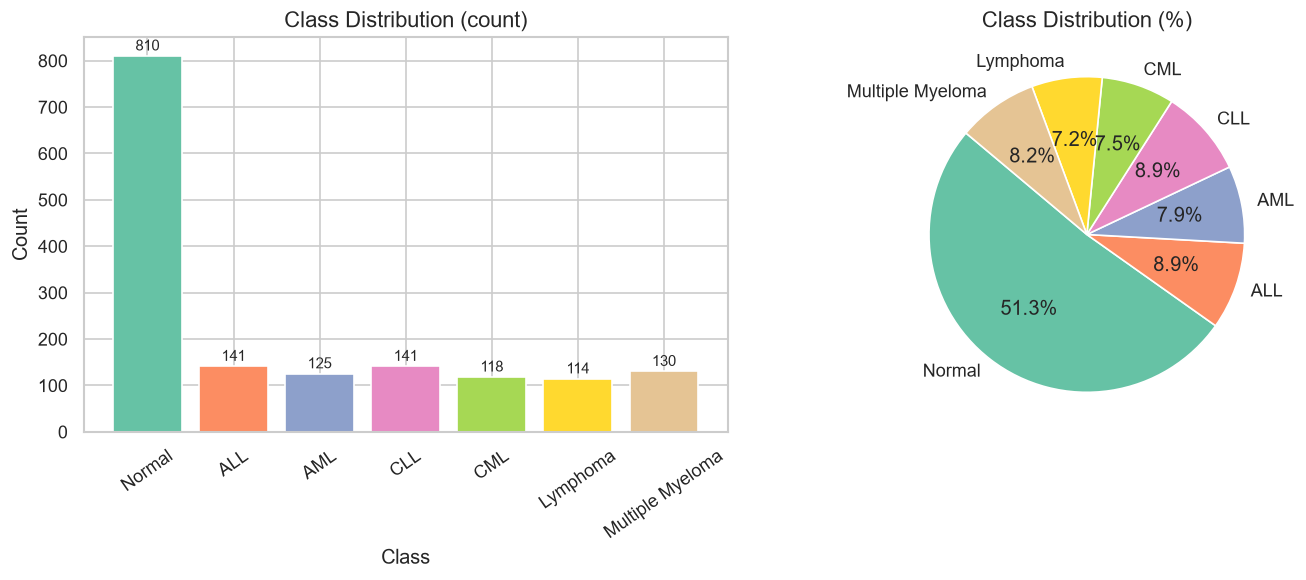

Saved: outputs/eda/01_class_distribution.png


In [3]:
vc = df['label'].value_counts().reindex(CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(vc.index, vc.values,
                   color=[PALETTE[c] for c in vc.index], edgecolor='white')
axes[0].set_title('Class Distribution (count)', fontsize=13)
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[PALETTE[c] for c in vc.index], startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.tight_layout()
fig.savefig(OUT / '01_class_distribution.png')
plt.show()
print('Saved: outputs/eda/01_class_distribution.png')


### Chart 2 — Missing Values

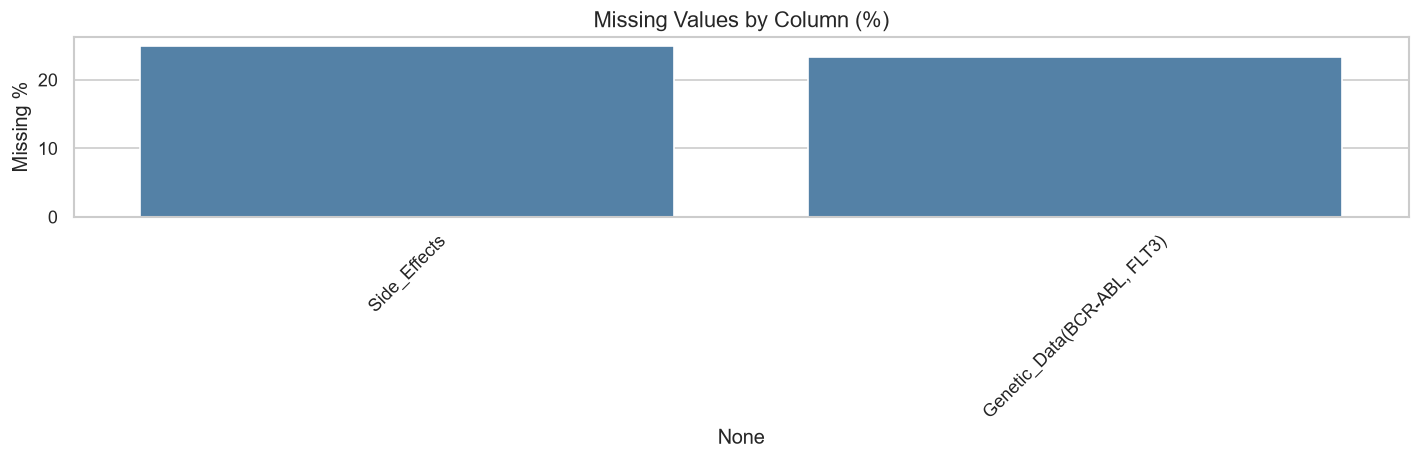

Saved: outputs/eda/02_missing_values.png


In [4]:
miss_pct = df.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
if miss_pct.empty:
    ax.text(0.5, 0.5, 'No missing values in any column',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.set_title('Missing Value Analysis')
else:
    sns.barplot(x=miss_pct.index, y=miss_pct.values, ax=ax, color='steelblue')
    ax.set_title('Missing Values by Column (%)', fontsize=13)
    ax.set_ylabel('Missing %')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(OUT / '02_missing_values.png')
plt.show()
print('Saved: outputs/eda/02_missing_values.png')


### Chart 3 — CBC Feature Distributions per Class
_Synthetic columns — distributions reflect sampled reference ranges._

C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\1184006743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


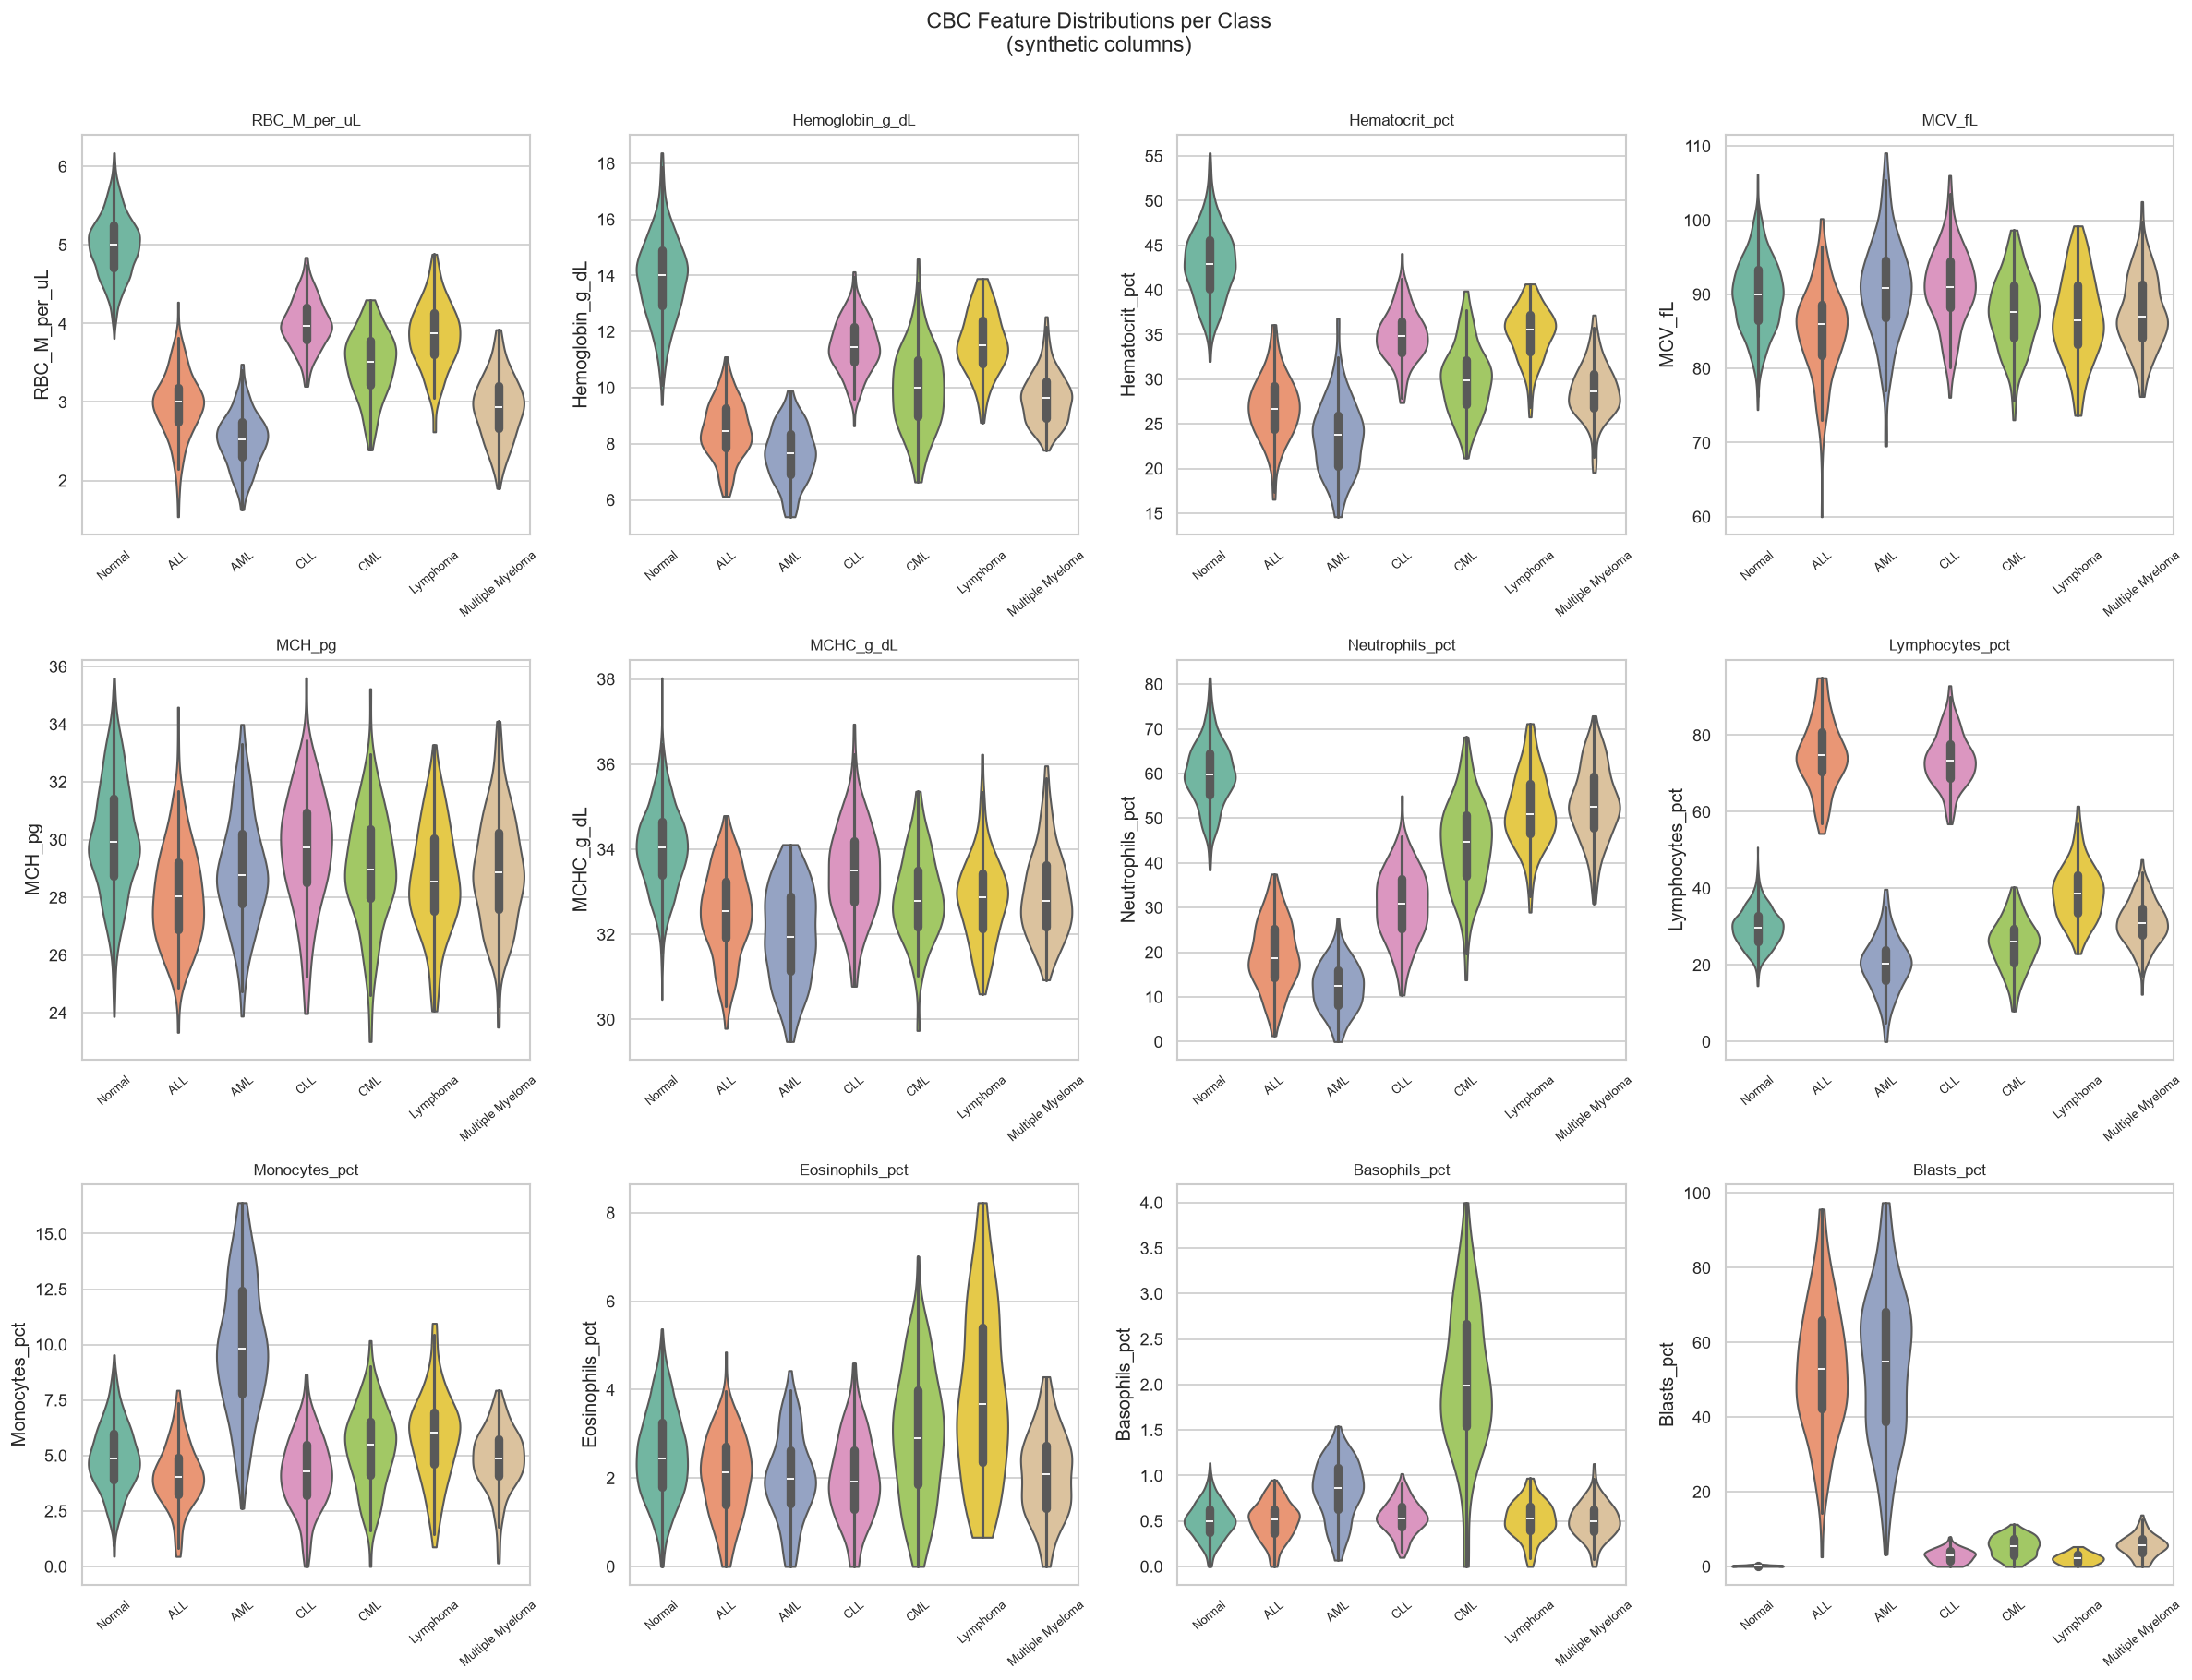

Saved: outputs/eda/03_cbc_violin_plots.png


In [5]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(CBC_COLS):
    sns.violinplot(
        data=df, x='label', y=col, palette=PALETTE,
        order=CLASSES, ax=axes[i], inner='box', cut=0,
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40, labelsize=8)

plt.suptitle('CBC Feature Distributions per Class\n(synthetic columns)',
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT / '03_cbc_violin_plots.png')
plt.show()
print('Saved: outputs/eda/03_cbc_violin_plots.png')


### Chart 4 — Feature Correlation Heatmap

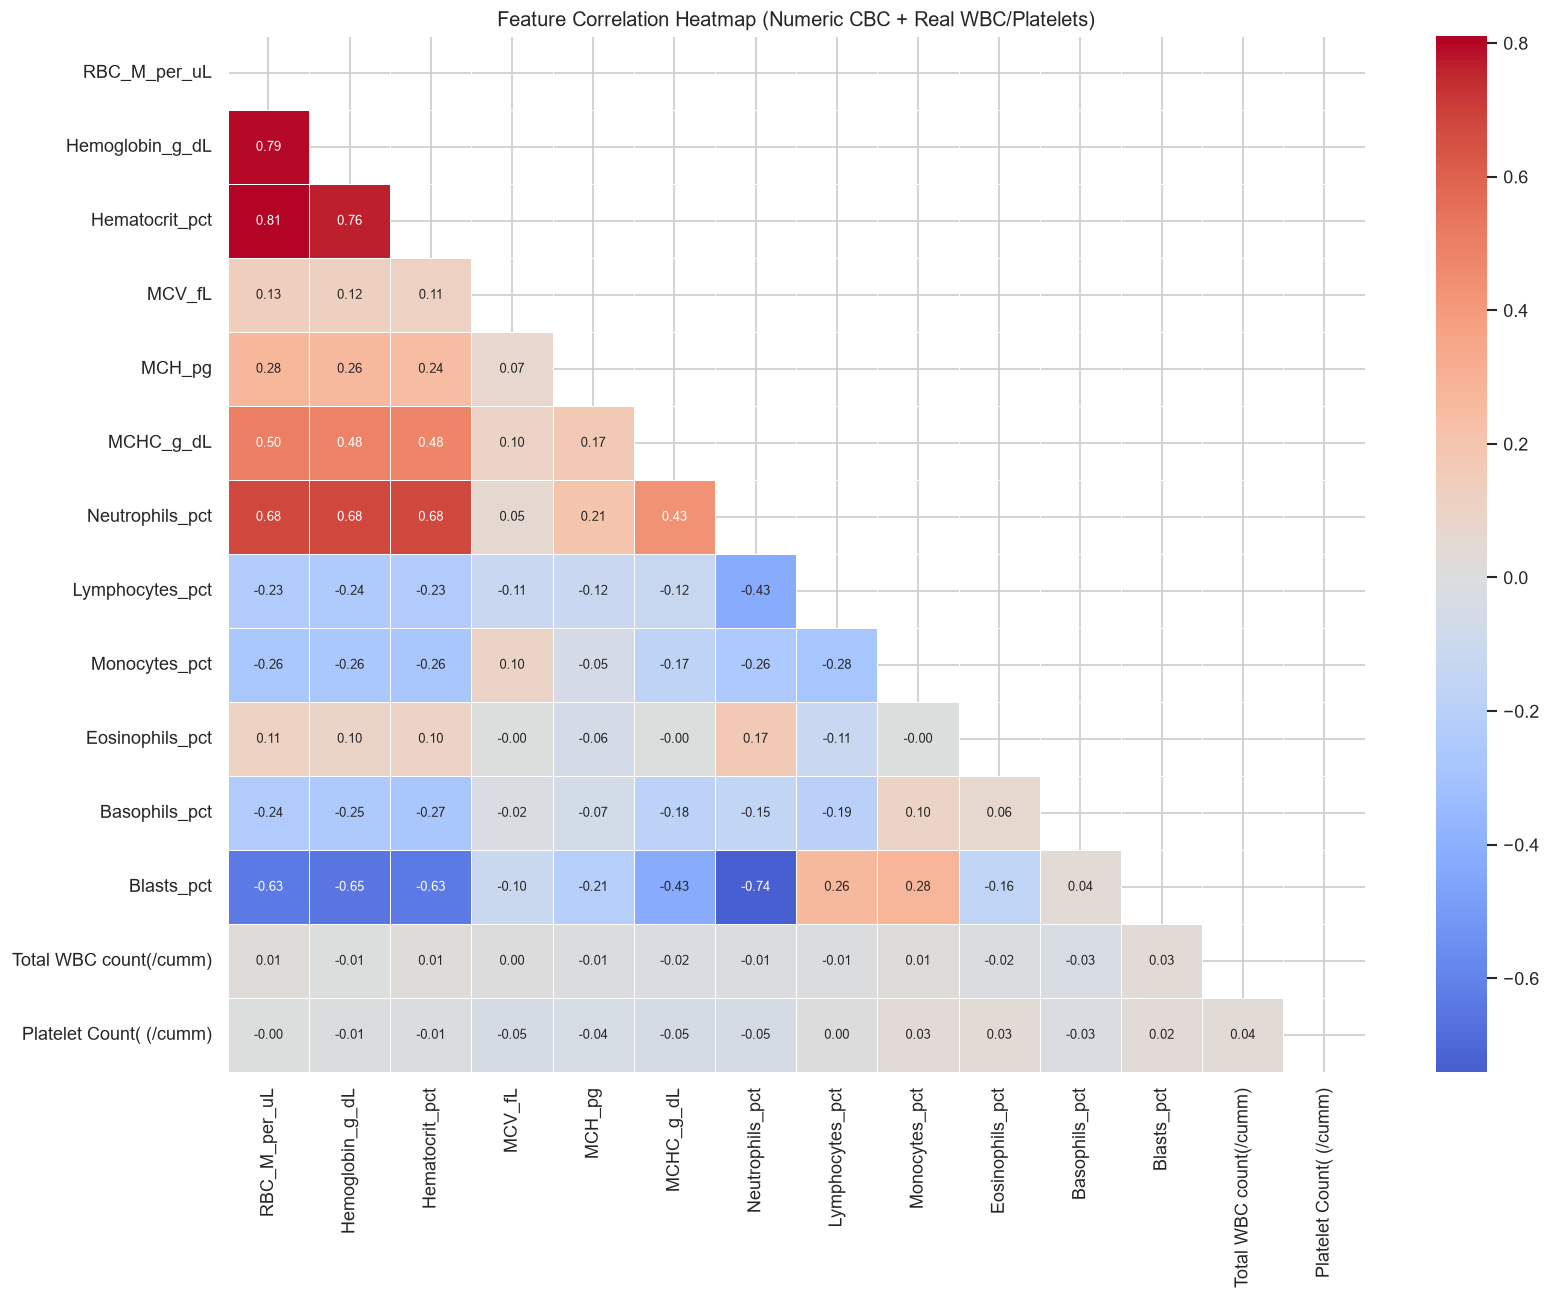

Saved: outputs/eda/04_correlation_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[ALL_NUM].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8},
)
ax.set_title('Feature Correlation Heatmap (Numeric CBC + Real WBC/Platelets)',
             fontsize=12)
plt.tight_layout()
fig.savefig(OUT / '04_correlation_heatmap.png')
plt.show()
print('Saved: outputs/eda/04_correlation_heatmap.png')


### Chart 5 — Real WBC & Platelet Counts per Class
_These are the unmodified Mendeley values._

C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\566697541.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=PALETTE,
C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\566697541.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=PALETTE,


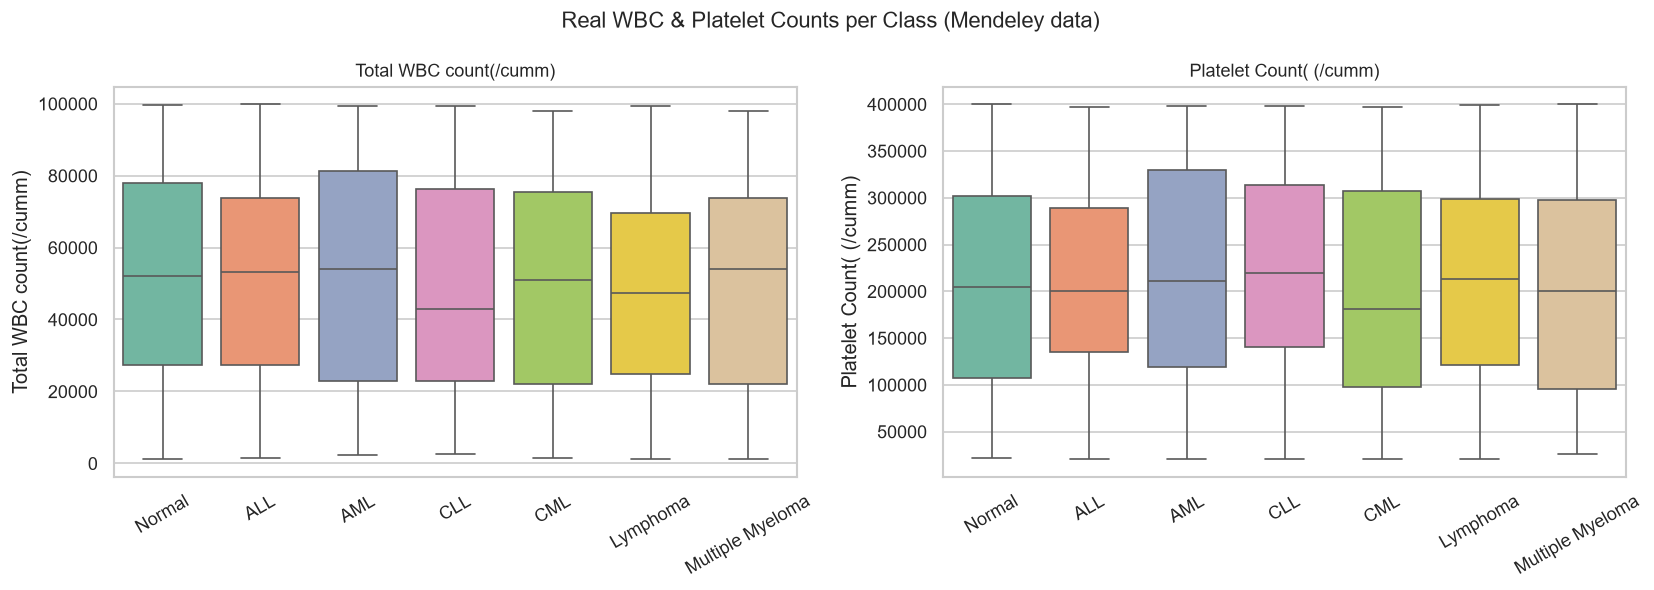

Saved: outputs/eda/05_wbc_platelets_boxplot.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, REAL_NUM):
    sns.boxplot(data=df, x='label', y=col, palette=PALETTE,
                order=CLASSES, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Real WBC & Platelet Counts per Class (Mendeley data)',
             fontsize=13)
plt.tight_layout()
fig.savefig(OUT / '05_wbc_platelets_boxplot.png')
plt.show()
print('Saved: outputs/eda/05_wbc_platelets_boxplot.png')


### Chart 6 — Age Distribution per Class

C:\Users\irfan\AppData\Local\Temp\ipykernel_36160\568557482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='Age', palette=PALETTE,


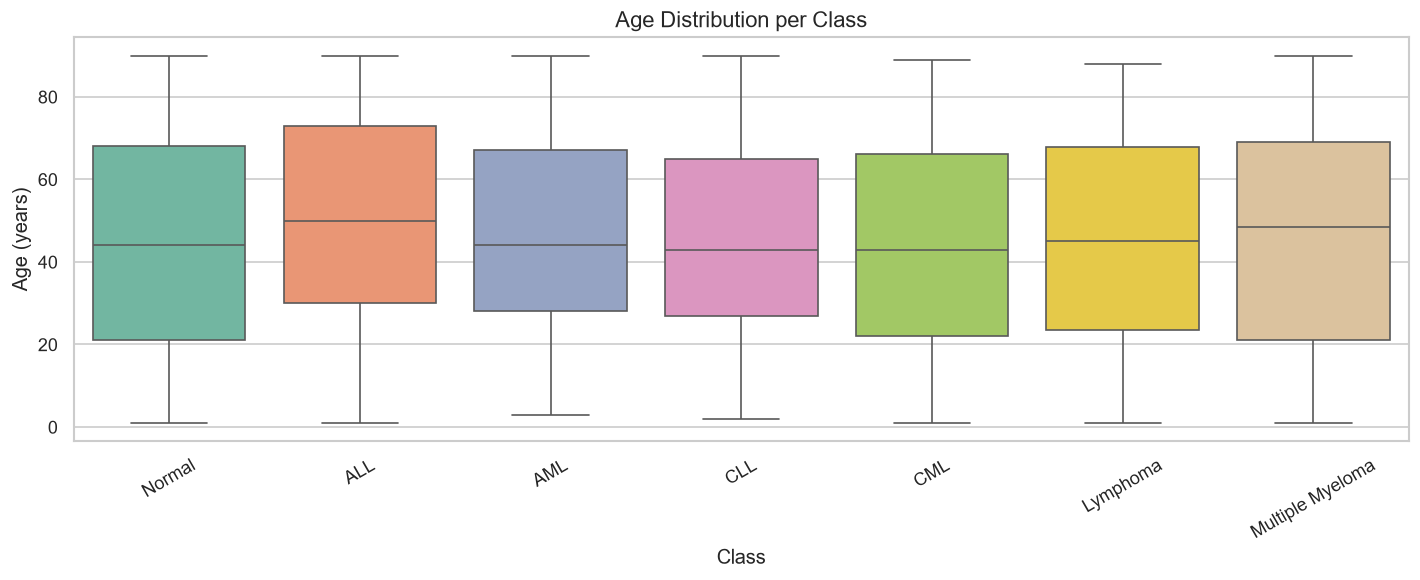

Saved: outputs/eda/06_age_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='label', y='Age', palette=PALETTE,
            order=CLASSES, ax=ax)
ax.set_title('Age Distribution per Class', fontsize=13)
ax.set_xlabel('Class'); ax.set_ylabel('Age (years)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig(OUT / '06_age_distribution.png')
plt.show()
print('Saved: outputs/eda/06_age_distribution.png')


## Key EDA Observations

| Feature | Observation |
|---|---|
| **Class balance** | Normal (810) vs. Lymphoma (114) — ~7:1 imbalance. Address with SMOTE or class-weighted models in Phase 3. |
| **Blasts_pct** | Strongest discriminator: ALL/AML spike to ~55%; CLL/CML/Lymphoma stay low. |
| **Lymphocytes_pct** | High in ALL (~75%) and CLL (~75%); low in AML and Normal. |
| **Hemoglobin / RBC** | Lowest in AML and Multiple Myeloma — reflects marrow failure and plasma-cell replacement. |
| **Basophils_pct** | Elevated only in CML — a known diagnostic hallmark. |
| **Eosinophils_pct** | Mildly elevated in Lymphoma (Hodgkin's association). |
| **WBC / Platelets** | High variance (real Mendeley values); outliers visible in CML (very high WBC). |
| **Age** | Broadly similar across classes; slight skew toward older patients in CLL and Multiple Myeloma. |

All charts saved to `outputs/eda/`. Numeric summary at `reports/phase2_eda_summary.txt`.

> **Reminder:** Violin/box plot separability confirms the CBC reference ranges encode clinically distinct signal per class — the synthetic augmentation is working as intended.